# Benchmark de memória: streaming versus abordagem ingênua

## Objetivo

Este notebook compara duas formas de filtrar o mesmo prefixo de um SEG-Y. A abordagem ingênua mantém todas as amplitudes selecionadas e todo o resultado na memória. A abordagem streaming lê, filtra e grava um chunk por vez. O objetivo é observar como o pico de memória muda quando aumentamos o número de traços, sem tentar carregar o survey completo ou provocar falta de memória.

**A aplicação GIECAR Seismic usa a abordagem streaming.** A implementação ingênua aparece somente como referência controlada neste benchmark e não faz parte do pipeline de produção.

## Por que medir memória

Arquivos sísmicos podem superar 25 GB. Para `N` traços e `S` amostras, a entrada da abordagem ingênua cresce aproximadamente com `N × S`. O filtro também cria a saída e buffers temporários, então o pico real pode ser bem maior que o tamanho bruto da entrada.

No streaming, com chunk de tamanho `C`, o componente principal de amplitudes cresce aproximadamente com `C × S`, e não com o total `N`. A memória não é literalmente constante: Python, SciPy, HDF5, SEG-Y, bibliotecas nativas e o sistema operacional têm custos fixos. A afirmação testada aqui é mais específica: as amplitudes em trabalho ficam limitadas pelo chunk.

In [1]:
import json
import os
import platform
import subprocess
import sys
import tempfile
from datetime import datetime
from importlib.metadata import version
from pathlib import Path
from types import SimpleNamespace

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import segyio

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SOURCE_PATH = PROJECT_ROOT / 'data' / 'survey.segy'  # altere aqui, se necessário
CHUNK_SIZE = 256
TRACE_COUNTS = [4_096, 16_384, 65_536]
REPETITIONS = 3
CUTOFF_HZ = 30.0
ORDER = 4
MAX_RAW_INPUT_MB = 256.0
ESTIMATED_WORKING_MULTIPLIER = 6.0
MAX_AVAILABLE_MEMORY_FRACTION = 0.50
RUNNER_PATH = PROJECT_ROOT / 'benchmarks' / 'memory_benchmark.py'

def build_runner_command(strategy, trace_count, repetition, output_path=None):
    command = [sys.executable, str(RUNNER_PATH), '--source', str(SOURCE_PATH), '--strategy', strategy, '--trace-count', str(trace_count), '--chunk-size', str(CHUNK_SIZE), '--cutoff', str(CUTOFF_HZ), '--order', str(ORDER), '--repetition', str(repetition), '--max-input-mb', str(MAX_RAW_INPUT_MB)]
    if output_path is not None:
        command.extend(['--output', str(output_path)])
    return command

## Dataset utilizado

O caminho padrão é relativo ao repositório e pode ser alterado em `SOURCE_PATH`. O número de traços vem diretamente de `segy.tracecount`; nenhuma dimensão geométrica é multiplicada para inferi-lo. Antes de executar, fazemos uma estimativa conservadora e recusamos automaticamente cenários acima dos limites configurados.

In [2]:
if not SOURCE_PATH.is_file():
    raise FileNotFoundError(
        f'SEG-Y não encontrado em {SOURCE_PATH}. Ajuste SOURCE_PATH na célula de configuração.'
    )

with segyio.open(SOURCE_PATH, mode='r', ignore_geometry=True) as segy:
    amplitude_dtype = np.dtype(segy.dtype)
    sample_rate_ms = float(segyio.tools.dt(segy)) / 1000
    metadata = SimpleNamespace(file_size_bytes=SOURCE_PATH.stat().st_size, trace_count=segy.tracecount, sample_count=len(segy.samples), sample_rate_ms=sample_rate_ms, nyquist_hz=500 / sample_rate_ms, dtype=str(amplitude_dtype), bytes_per_sample=amplitude_dtype.itemsize)
if not 0 < CUTOFF_HZ < metadata.nyquist_hz:
    raise ValueError(f'Cutoff de {CUTOFF_HZ} Hz deve ser menor que Nyquist ({metadata.nyquist_hz} Hz).')

dataset_info = pd.DataFrame({
    'Item': ['Arquivo', 'Tamanho', 'Traços físicos', 'Amostras por traço', 'Sample rate', 'Nyquist', 'dtype', 'Chunk size'],
    'Valor': [SOURCE_PATH.name, f'{metadata.file_size_bytes / 1024**3:.3f} GiB', metadata.trace_count, metadata.sample_count, f'{metadata.sample_rate_ms:g} ms', f'{metadata.nyquist_hz:g} Hz', metadata.dtype, CHUNK_SIZE],
})
dataset_info

,Item,Valor
0,Arquivo,survey.segy
1,Tamanho,0.979 GiB
2,Traços físicos,288694
3,Amostras por traço,850
4,Sample rate,4 ms
5,Nyquist,125 Hz
6,dtype,float32
7,Chunk size,256


In [3]:
def available_memory_mb():
    meminfo = Path('/proc/meminfo')
    if not meminfo.exists():
        return None
    for line in meminfo.read_text().splitlines():
        if line.startswith('MemAvailable:'):
            return float(line.split()[1]) / 1024
    return None

available_mb = available_memory_mb()
safety_rows = []
for trace_count in TRACE_COUNTS:
    raw_mb = trace_count * metadata.sample_count * metadata.bytes_per_sample / 1024**2
    estimated_working_mb = raw_mb * ESTIMATED_WORKING_MULTIPLIER
    safe = (
        trace_count <= metadata.trace_count
        and raw_mb <= MAX_RAW_INPUT_MB
        and (available_mb is None or estimated_working_mb <= available_mb * MAX_AVAILABLE_MEMORY_FRACTION)
    )
    safety_rows.append({'trace_count': trace_count, 'raw_input_mb': raw_mb, 'conservative_estimate_mb': estimated_working_mb, 'safe_to_run': safe})
safety_df = pd.DataFrame(safety_rows)
if not safety_df['safe_to_run'].all():
    raise RuntimeError('Há um cenário acima do limite de segurança. Reduza TRACE_COUNTS antes de executar.')
print(f'Memória disponível observada: {available_mb:.1f} MB' if available_mb else 'Memória disponível não detectada; vale apenas o limite bruto explícito.')
safety_df

Memória disponível observada: 6449.2 MB


,trace_count,raw_input_mb,conservative_estimate_mb,safe_to_run
0,4096,13.28125,79.6875,True
1,16384,53.12500,318.7500,True
2,65536,212.50000,1275.0000,True


## Metodologia

### Abordagem ingênua

O runner chama `reader.read_chunk(0, trace_limit)`, aplica `apply_lowpass_filter` ao array completo e mantém entrada e resultado até gravar o HDF5. É uma implementação direta e realista, sem cópias artificiais para piorar o resultado.

### Abordagem streaming

O mesmo reader percorre `[0, trace_limit)` em chunks de 256 traços. Cada chunk passa pelo mesmo `apply_lowpass_filter`, é gravado no mesmo formato HDF5 e tem suas referências liberadas antes da próxima leitura.

As duas estratégias usam Low-pass Butterworth de ordem 4, cutoff de 30 Hz, SOS e `sosfiltfilt`, por meio da implementação real do projeto. O runner usa `h5py` diretamente para criar o mesmo dataset temporário nas duas estratégias; assim, a medição não depende de Job, SQLite ou máquina de estados. A única diferença relevante é materializar o prefixo inteiro ou processá-lo em partes.

## Como o pico de memória é medido

Cada combinação de estratégia, quantidade de traços e repetição roda em um processo separado e descartável. Isso evita que o allocator do kernel do Jupyter contamine a medição seguinte. No Linux, o runner lê `resource.getrusage(...).ru_maxrss` e converte de KiB para MiB. RSS representa a memória residente do processo observada pelo sistema operacional.

O baseline importa as mesmas bibliotecas, abre o SEG-Y, obtém metadados e abre o reader, sem materializar amplitudes. `additional_peak_mb` subtrai a mediana desse baseline. É uma aproximação útil para comparação, não uma medição perfeita de cada objeto ou buffer.

## Sanity check de equivalência numérica

Antes das medições maiores, comparamos 1.024 traços fora do benchmark de RSS. A leitura da comparação também é limitada ao necessário para esse pequeno prefixo.

In [4]:
SANITY_TRACES = 1_024
with tempfile.TemporaryDirectory(prefix='giecar-memory-sanity-') as directory:
    directory = Path(directory)
    naive_path = directory / 'naive.h5'
    streaming_path = directory / 'streaming.h5'
    subprocess.run(build_runner_command('naive', SANITY_TRACES, 0, naive_path), cwd=PROJECT_ROOT, check=True, capture_output=True, text=True)
    subprocess.run(build_runner_command('streaming', SANITY_TRACES, 0, streaming_path), cwd=PROJECT_ROOT, check=True, capture_output=True, text=True)
    with h5py.File(naive_path, 'r') as naive_file, h5py.File(streaming_path, 'r') as streaming_file:
        naive_result = naive_file['traces'][:]
        streaming_result = streaming_file['traces'][:]
        np.testing.assert_allclose(naive_result, streaming_result, rtol=1e-5, atol=1e-6)
        max_difference = float(np.max(np.abs(naive_result - streaming_result)))
print(f'Equivalência confirmada para {SANITY_TRACES} traços; diferença máxima = {max_difference:.3e}.')

Equivalência confirmada para 1024 traços; diferença máxima = 0.000e+00.


## Informações do ambiente

Estas informações ajudam a interpretar e reproduzir os números sem registrar caminhos pessoais.

In [5]:
try:
    commit = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=PROJECT_ROOT, check=True, capture_output=True, text=True).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    commit = 'não disponível'
environment_df = pd.DataFrame({
    'Item': ['Data/hora', 'Sistema', 'Python', 'CPUs', 'NumPy', 'SciPy', 'segyio', 'h5py', 'Commit'],
    'Valor': [datetime.now().astimezone().isoformat(timespec='seconds'), platform.platform(), platform.python_version(), os.cpu_count(), np.__version__, scipy.__version__, version('segyio'), h5py.__version__, commit],
})
environment_df

,Item,Valor
0,Data/hora,2026-09-12T16:26:56-03:00
1,Sistema,Linux-7.2.3-1-cachyos-x86_64-with-glibc2.44
2,Python,3.12.14
3,CPUs,16
4,NumPy,2.5.3
5,SciPy,1.18.1
6,segyio,1.9.14
7,h5py,3.16.0
8,Commit,bdfe954


## Execução do benchmark

Executamos três baselines e depois três repetições para cada estratégia e prefixo. O runner devolve uma única linha JSON; os HDF5 temporários são removidos ao fim de cada subprocesso.

In [6]:
def run_isolated(strategy, trace_count, repetition):
    with tempfile.TemporaryDirectory(prefix='giecar-memory-benchmark-') as directory:
        output_path = None if strategy == 'baseline' else Path(directory) / 'result.h5'
        command = build_runner_command(strategy, trace_count, repetition, output_path)
        completed = subprocess.run(command, cwd=PROJECT_ROOT, check=True, capture_output=True, text=True)
        return json.loads(completed.stdout)

In [7]:
baseline_runs = [run_isolated('baseline', 1, repetition) for repetition in range(1, REPETITIONS + 1)]
baseline_peak_rss_mb = float(np.median([row['peak_rss_mb'] for row in baseline_runs]))
records = []
for strategy in ('naive', 'streaming'):
    for trace_count in TRACE_COUNTS:
        for repetition in range(1, REPETITIONS + 1):
            row = run_isolated(strategy, trace_count, repetition)
            row['baseline_peak_rss_mb'] = baseline_peak_rss_mb
            row['additional_peak_mb'] = row['peak_rss_mb'] - baseline_peak_rss_mb
            records.append(row)
print(f'{len(records)} execuções concluídas; baseline mediano = {baseline_peak_rss_mb:.1f} MB.')

18 execuções concluídas; baseline mediano = 165.7 MB.


## Resultados

A primeira tabela preserva cada execução. A segunda usa a mediana por estratégia e quantidade de traços. O tempo é secundário neste experimento.

In [8]:
results_df = pd.DataFrame(records)[['strategy', 'trace_count', 'sample_count', 'input_size_mb', 'chunk_size', 'repetition', 'peak_rss_mb', 'baseline_peak_rss_mb', 'additional_peak_mb', 'elapsed_seconds']]
results_df.round(3)

,strategy,trace_count,sample_count,input_size_mb,chunk_size,repetition,peak_rss_mb,baseline_peak_rss_mb,additional_peak_mb,elapsed_seconds
0,naive,4096,850,13.281,256,1,197.559,165.746,31.812,0.088
1,naive,4096,850,13.281,256,2,197.883,165.746,32.137,0.105
2,naive,4096,850,13.281,256,3,197.559,165.746,31.812,0.089
3,naive,16384,850,53.125,256,1,445.238,165.746,279.492,0.335
4,naive,16384,850,53.125,256,2,445.398,165.746,279.652,0.356
5,naive,16384,850,53.125,256,3,444.996,165.746,279.250,0.380
6,naive,65536,850,212.500,256,1,1435.234,165.746,1269.488,2.790
7,naive,65536,850,212.500,256,2,1435.711,165.746,1269.965,2.770
8,naive,65536,850,212.500,256,3,1434.910,165.746,1269.164,2.674
9,streaming,4096,850,13.281,256,1,165.746,165.746,0.000,0.123


In [9]:
summary_df = (results_df.groupby(['strategy', 'trace_count'], as_index=False).agg(sample_count=('sample_count', 'first'), input_size_mb=('input_size_mb', 'first'), chunk_size=('chunk_size', 'first'), median_peak_rss_mb=('peak_rss_mb', 'median'), median_additional_peak_mb=('additional_peak_mb', 'median'), median_elapsed_seconds=('elapsed_seconds', 'median')))
summary_df.round(3)

,strategy,trace_count,sample_count,input_size_mb,chunk_size,median_peak_rss_mb,median_additional_peak_mb,median_elapsed_seconds
0,naive,4096,850,13.281,256,197.559,31.812,0.089
1,naive,16384,850,53.125,256,445.238,279.492,0.356
2,naive,65536,850,212.500,256,1435.234,1269.488,2.770
3,streaming,4096,850,13.281,256,165.746,0.000,0.123
4,streaming,16384,850,53.125,256,165.746,0.000,0.486
5,streaming,65536,850,212.500,256,165.746,0.000,2.082


## Gráficos

O primeiro gráfico mostra o pico RSS absoluto. O segundo remove o baseline mediano para destacar a parcela adicional associada ao trabalho medido.

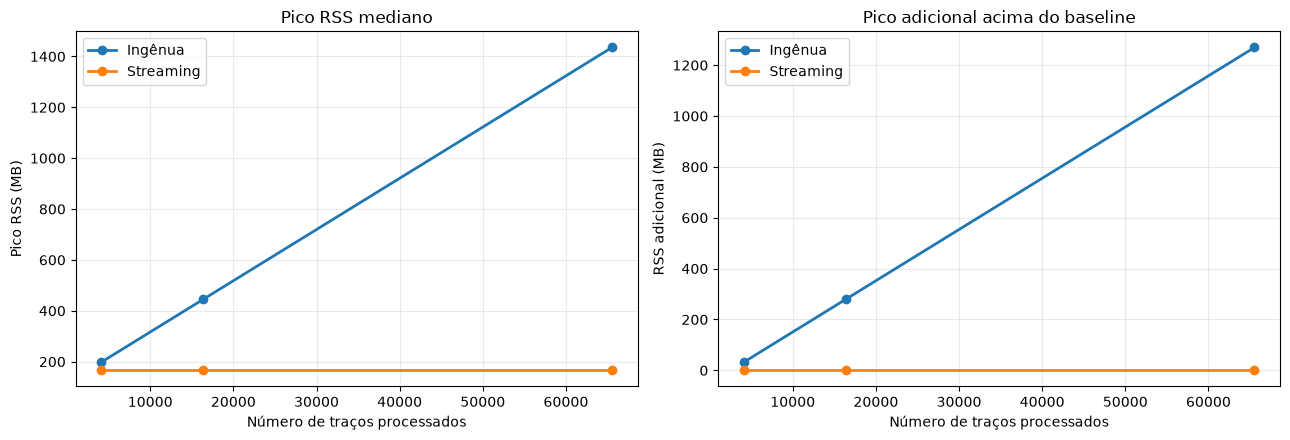

In [10]:
labels = {'naive': 'Ingênua', 'streaming': 'Streaming'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for strategy, group in summary_df.groupby('strategy'):
    ordered = group.sort_values('trace_count')
    axes[0].plot(ordered['trace_count'], ordered['median_peak_rss_mb'], marker='o', linewidth=2, label=labels[strategy])
    axes[1].plot(ordered['trace_count'], ordered['median_additional_peak_mb'], marker='o', linewidth=2, label=labels[strategy])
axes[0].set(title='Pico RSS mediano', xlabel='Número de traços processados', ylabel='Pico RSS (MB)')
axes[1].set(title='Pico adicional acima do baseline', xlabel='Número de traços processados', ylabel='RSS adicional (MB)')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
    axis.ticklabel_format(style='plain', axis='x')
fig.tight_layout()
plt.show()

## Interpretação

A célula abaixo deriva as frases dos valores medidos. Nenhuma razão de economia foi definida antes da execução.

In [11]:
naive = summary_df[summary_df.strategy == 'naive'].sort_values('trace_count')
streaming = summary_df[summary_df.strategy == 'streaming'].sort_values('trace_count')
largest_naive = naive.iloc[-1]
largest_streaming = streaming.iloc[-1]
print(f"Ingênua: {naive.iloc[0].median_peak_rss_mb:.1f} → {largest_naive.median_peak_rss_mb:.1f} MB ao passar de {int(naive.iloc[0].trace_count):,} para {int(largest_naive.trace_count):,} traços.")
print(f"Streaming: {streaming.median_peak_rss_mb.min():.1f} a {streaming.median_peak_rss_mb.max():.1f} MB nos mesmos prefixos.")
print(f"No maior prefixo, a diferença de pico foi {largest_naive.median_peak_rss_mb - largest_streaming.median_peak_rss_mb:.1f} MB.")

Ingênua: 197.6 → 1435.2 MB ao passar de 4,096 para 65,536 traços.
Streaming: 165.7 a 165.7 MB nos mesmos prefixos.
No maior prefixo, a diferença de pico foi 1269.5 MB.


## Limitações do benchmark

- `ru_maxrss` informa o maior RSS observado durante todo o processo, não atribui memória a objetos específicos.
- A subtração do baseline é aproximada e sofre influência do allocator, page cache, bibliotecas nativas e carga do sistema.
- Os processos são isolados, mas o sistema operacional pode manter o cache do arquivo entre repetições. Isso afeta principalmente tempo; o foco aqui é memória.
- O experimento usa prefixos de um único survey e um único filtro. Outros formatos, tamanhos de amostra e versões das bibliotecas podem produzir números diferentes.
- O maior caso ingênuo foi deliberadamente limitado. Carregar os 288 mil traços apenas para aumentar o pico seria desnecessário e poderia causar OOM.

## Conclusão

Os números e gráficos acima mostram o comportamento observado nesta máquina e neste SEG-Y. A conclusão defensável é sobre a forma da alocação: a abordagem ingênua mantém amplitudes proporcionais ao prefixo inteiro, enquanto o streaming limita o componente principal de amplitudes ao chunk de 256 traços. **Esse streaming limitado por chunk é a abordagem usada no pipeline de produção do projeto.** Os valores absolutos não devem ser generalizados para todas as máquinas.